# Chapter 7: Ensemble Learning and Random Forests

## Rafly Fasha Purnomo Putra
## 1103223050

## 1. Konsep Dasar: The Wisdom of the Crowd

Ide utama dari **Ensemble Learning** adalah **menggabungkan prediksi dari beberapa model** (classifier atau regressor) untuk mendapatkan hasil yang lebih baik daripada model terbaik sekalipun secara individual.  
Kelompok model ini disebut sebagai **Ensemble**.


## 2. Voting Classifiers

Cara termudah membuat model ensemble adalah melatih beberapa **classifier yang berbeda** (misal Logistic Regression, SVM, Random Forest) dan menggabungkan hasilnya:

- **Hard Voting**: Prediksi kelas yang mendapatkan suara terbanyak dari setiap model individu  
- **Soft Voting**: Jika semua model dapat memprediksi probabilitas kelas, ambil **rata-rata probabilitasnya**  
  - Biasanya memberikan performa lebih tinggi karena memberikan bobot lebih pada model yang "sangat yakin" dengan pilihannya


## 3. Bagging dan Pasting

Metode lain adalah menggunakan algoritma **yang sama** untuk setiap model, tetapi melatihnya pada **subset acak berbeda** dari data training:

- **Bagging (Bootstrap Aggregating)**:  
  - Sampel diambil **secara acak dengan pengembalian (replacement)**  
  - Artinya, satu data bisa muncul berkali-kali di satu subset pelatihan  

- **Pasting**:  
  - Sampel diambil **secara acak tanpa pengembalian**  

- **Out-of-Bag (OOB) Evaluation**:  
  - Pada Bagging, sekitar **37% data tidak terlihat** oleh model selama pelatihan  
  - Data ini bisa digunakan untuk **evaluasi model tanpa test set tambahan**

## 4. Random Forests

**Random Forest** adalah ansambel dari **Decision Trees** yang dilatih melalui metode **bagging**.  
Algoritma ini menambahkan **ekstra acak** saat menumbuhkan pohon:  
- Alih-alih mencari fitur terbaik di setiap node dari seluruh fitur, Random Forest mencari fitur terbaik dari **subset fitur acak**  

- **Kelebihan**: Sangat stabil dan kuat terhadap overfitting  
- **Feature Importance**: Random Forest dapat menghitung **seberapa penting setiap fitur** dalam prediksi, sangat berguna untuk analisis data

## 5. Boosting

**Boosting** adalah metode ensemble yang melatih model secara **berurutan (sequential)**, di mana setiap model mencoba **memperbaiki kesalahan pendahulunya**:

- **AdaBoost (Adaptive Boosting)**:  
  - Model berikutnya fokus pada **data yang salah diklasifikasikan** oleh model sebelumnya  
  - Dilakukan dengan **meningkatkan bobot data** yang sulit  

- **Gradient Boosting**:  
  - Alih-alih mengubah bobot data, model baru mencoba memprediksi **residual error**  
  - Residual = selisih antara **prediksi model sebelumnya** dan **nilai asli**


## 6. Stacking (Stacked Generalization)

**Stacking** menggunakan pendekatan berbeda daripada voting:  
- Melatih sebuah **model tambahan** (disebut **blender** atau **meta-learner**)  
- Model ini **mempelajari cara terbaik** menggabungkan prediksi dari semua model individu dalam ensemble

## **Contoh Kode: Perbandingan Model Tunggal vs Voting Classifier**

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Menghasilkan data bulan (moons dataset)
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Inisialisasi beberapa model berbeda
log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(probability=True, random_state=42)

# 3. Membuat Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='soft'
)

# 4. Evaluasi performa masing-masing
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"{clf.__class__.__name__}: {accuracy_score(y_test, y_pred):.4f}")

LogisticRegression: 0.8640
RandomForestClassifier: 0.8960
SVC: 0.8960
VotingClassifier: 0.9200


## 8. Analisis Pentingnya Fitur (Feature Importance)

Salah satu keuntungan besar menggunakan **Random Forest** adalah kemampuannya untuk mengukur **seberapa penting setiap fitur** dalam pengambilan keputusan:

- **Cara Kerja**:  
  - Scikit-Learn menghitung seberapa banyak **node pohon** yang menggunakan fitur tersebut untuk **mengurangi impurity** (ketidakmurnian) di seluruh pohon dalam hutan  

- **Kegunaan**:  
  - Sangat membantu dalam **Feature Selection**  
  - Fitur dengan kepentingan mendekati **nol** bisa dibuang untuk:  
    - Menyederhanakan model  
    - Mempercepat proses training

# Chapter 8: Dimensionality Reduction

## 1. The Curse of Dimensionality

Banyak fitur dalam dataset seringkali **tidak berguna atau saling tumpang tindih**.  
Semakin banyak dimensi (fitur) yang dimiliki, semakin **renggang jarak antar titik data** dalam ruang tersebut. Hal ini membuat model:

- Menjadi sangat **lambat** saat dilatih  
- Mudah mengalami **Overfitting**, karena model mencari pola pada **noise dimensi tinggi**


## 2. Pendekatan Utama untuk Reduksi Dimensi

Ada dua metode utama untuk **mengurangi jumlah fitur**:

- **Projection (Proyeksi)**:  
  - Memproyeksikan titik data dari ruang dimensi tinggi (misal 3D) ke bidang dimensi yang lebih rendah (misal 2D)  
  - Metode paling populer: **PCA (Principal Component Analysis)**  

- **Manifold Learning**:  
  - Digunakan jika data "tergulung" (seperti gulungan **Swiss Roll**)  
  - Proyeksi linear bisa **merusak struktur data**, jadi manifold learning mencoba "**membuka gulungan**" tersebut


## 3. Principal Component Analysis (PCA)

**PCA** adalah algoritma reduksi dimensi paling populer. Cara kerjanya:

- Mengidentifikasi **bidang (hyperplane)** yang paling dekat dengan data  
- Memproyeksikan data ke bidang tersebut sedemikian rupa sehingga **varians data tetap maksimal**

**Komponen Utama (Principal Components)**:

- **PC1**: Sumbu yang mempertahankan **varians paling banyak**

## 4. Memilih Jumlah Dimensi yang Tepat

Alih-alih memilih jumlah dimensi secara sembarangan, sebaiknya pilih jumlah dimensi yang mampu **mempertahankan persentase varians yang cukup besar** (misal **95% varians**).


## 5. Incremental PCA (IPCA)

PCA biasa mengharuskan seluruh dataset masuk ke **memori (RAM)**.  

Jika dataset sangat besar, gunakan **Incremental PCA (IPCA)**:

- Data dibagi menjadi **batch kecil**  
- Diproses secara bertahap  
- Mengurangi kebutuhan memori tanpa kehilangan informasi utama

## 6. LLE (Locally Linear Embedding)

**LLE** adalah teknik **Manifold Learning** yang kuat. Cara kerjanya:

- Mengukur hubungan **setiap sampel dengan tetangga terdekat**  
- Mencari representasi dimensi rendah di mana **hubungan lokal tetap terjaga**  
- Cocok untuk data non-linear yang memiliki struktur kompleks

## **Contoh Kode: Implementasi PCA dengan Scikit-Learn**

Explained Variance Ratio: [0.40782396 0.3020019 ]
Total Varians Terjaga: 0.71


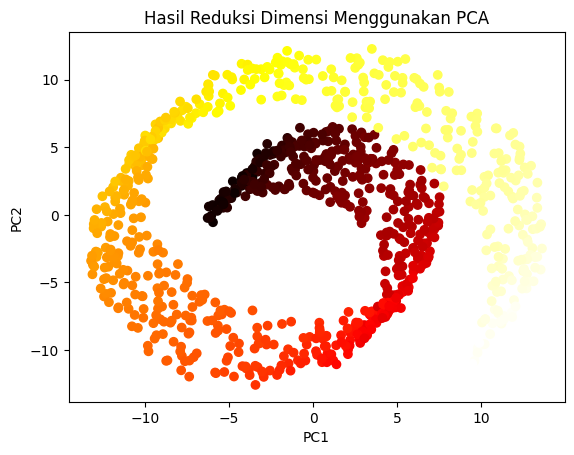

In [2]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import make_swiss_roll

# 1. Menghasilkan data simulasi (Swiss Roll)
X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

# 2. Menggunakan PCA untuk mengurangi dari 3D ke 2D
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

# 3. Melihat rasio varians yang dipertahankan
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Varians Terjaga: {np.sum(pca.explained_variance_ratio_):.2f}")

# 4. Visualisasi hasil (Opsional)
import matplotlib.pyplot as plt
plt.scatter(X2D[:, 0], X2D[:, 1], c=t, cmap=plt.cm.hot)
plt.title("Hasil Reduksi Dimensi Menggunakan PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 8. Analisis Hasil: Mengapa PCA Gagal pada Swiss Roll?

Jika melihat visualisasi, titik-titik warna yang seharusnya membentuk urutan (seperti pelangi) **terlihat bertumpuk atau bercampur**.  

**Masalah**: PCA adalah teknik **Linear**.  
- PCA memproyeksikan data ke bidang datar  
- Swiss Roll tergulung, sehingga proyeksi linear seperti "melindas kue gulung dengan silinder"  
- Semua lapisan akan **hancur dan tercampur**

**Solusi**: Gunakan **Manifold Learning** seperti **LLE (Locally Linear Embedding)** atau **t-SNE**.  
- Teknik ini "**membuka gulungan**" data  
- Struktur asli tetap terjaga di dimensi rendah

## 9. Menemukan Jumlah Dimensi Optimal (Elbow Method)

Dalam praktik nyata, kita **tidak menebak sembarangan** jumlah dimensi.  

**Langkah-langkah**:

- Plot **akumulasi varians** dari komponen utama  
- Cari titik "**siku (Elbow)**" pada grafik  
- Titik di mana menambah dimensi **tidak memberikan tambahan varians signifikan** dianggap jumlah dimensi optimal


# Chapter 9: Unsupervised Learning Techniques

Di bab-bab sebelumnya, kita selalu punya **label** atau jawaban benar (misal harga rumah atau jenis bunga).  
Di Chapter 9, kita berurusan dengan data **tanpa label**, sehingga algoritma harus **mencari pola atau struktur sendiri** dari data tersebut.

## 1. Clustering (Pengelompokan)

Tujuan utama clustering adalah menempatkan sampel yang **mirip** ke dalam **kelompok (cluster)** yang sama.

### A. K-Means

Algoritma ini mencari **pusat kelompok (centroids)** secara iteratif:

1. Letakkan centroid secara acak  
2. Labeli sampel berdasarkan centroid terdekat  
3. Update centroid ke rata-rata sampel dalam kelompok  
4. Ulangi sampai centroid **tidak berubah lagi**

**Kelemahan**:  
- Harus menentukan jumlah cluster ($k$) di awal  
- Sangat sensitif terhadap inisialisasi centroid buruk → bisa diatasi dengan **K-Means++**




### B. Cara Memilih Jumlah Cluster yang Tepat

- **Elbow Method**: Memplot Inertia (jarak kuadrat rata-rata sampel ke centroid). Pilih titik di mana penurunan mulai melambat drastis  
- **Silhouette Score**: Mengukur seberapa dekat sampel dengan clusternya sendiri dibanding cluster lain.  
  - +1 → sangat baik  
  - 0 → berada di batas  
  - -1 → salah cluster


### C. DBSCAN

- Mendefinisikan cluster berdasarkan **densitas** (kerapatan) titik  
- Bagus untuk cluster **berbentuk aneh** (tidak harus bulat)  
- Secara otomatis mendeteksi **outliers** (titik di area sepi)

## 2. Gaussian Mixtures Model (GMM)

- Model probabilistik yang mengasumsikan data berasal dari **campuran beberapa distribusi Gaussian**  
- Lebih fleksibel daripada K-Means → bisa menangani cluster **oval/lonjong**  
- Memberikan **probabilitas** sampel masuk ke suatu cluster, bukan hanya label kaku


## 3. Anomaly Detection (Deteksi Anomali)

Digunakan untuk mendeteksi data yang **aneh** atau tidak biasa (misal: transaksi kartu kredit mencurigakan)

**Teknik populer**:  
- Gaussian Mixture  
- Isolation Forest

## Contoh Kode: K-Means Clustering pada Data **Iris**

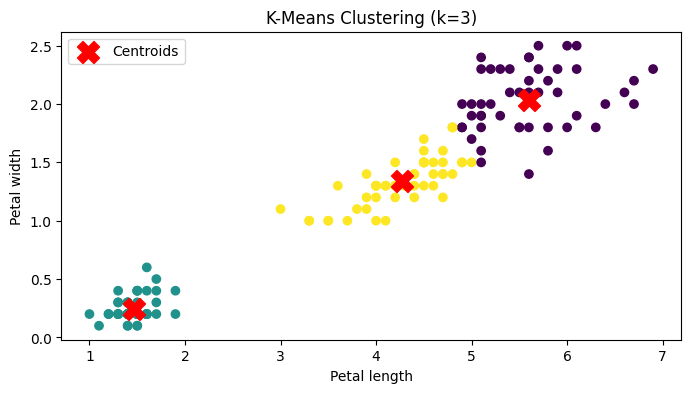

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# 1. Load data (Tanpa menggunakan label y)
iris = load_iris()
X = iris.data[:, 2:] # petal length and width

# 2. Melatih K-Means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

# 3. Visualisasi Cluster dan Centroids
plt.figure(figsize=(8, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, marker='X', c='red', label='Centroids')
plt.title(f"K-Means Clustering (k={k})")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend()
plt.show()

## 5. Menentukan Jumlah Cluster Optimal

Dalam dunia nyata, seringkali kita **tidak tahu berapa jumlah cluster**.  
Ada dua metode utama untuk menentukan jumlah cluster:

### A. Metode Elbow (Inertia)

- Memplot **Inertia**: jumlah kuadrat jarak antara sampel dan centroid terdekatnya  
- Saat $k$ bertambah, inersia akan turun  
- Cari titik **"siku" (elbow)** di mana penurunan inersia **tidak lagi drastis**  

### B. Silhouette Analysis

- Mengukur seberapa baik setiap sampel **pas** di clusternya  
- Interpretasi skor:  
  - +1 → Sampel jauh dari cluster tetangga (bagus)  
  - 0 → Sampel berada di ambang batas antara dua cluster  
  - -1 → Sampel kemungkinan besar berada di cluster yang salah  


## 6. Penggunaan Clustering untuk Preprocessing

Clustering tidak hanya untuk analisis data, tapi bisa digunakan sebagai **langkah awal sebelum algoritma lain**:

1. **Dimensionality Reduction**:  
   - Ganti fitur asli dengan **jarak sampel ke setiap centroid**  

2. **Semi-supervised Learning**:  
   - Jika punya banyak data tanpa label dan sedikit data berlabel  
   - Lakukan clustering lalu **sebarkan label** dari sampel berlabel ke seluruh anggota cluster yang sama (**Label Spreading**)